# Scenario walkthrough

One canonical scenario, run once through the full pipeline -- same section
order `DiscoveryReport` itself uses. Source of the numbers and charts for
`docs/overview.html`; not a report in itself, no polish needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from how_wrong_is_your_mmm import DiscoveryReport, simulate_demand, simulate_spend
from how_wrong_is_your_mmm._dgp import channel_contributions
from how_wrong_is_your_mmm._diagnostic import CollinearityDiagnostic

plt.rcParams["figure.figsize"] = (9, 3.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Same four channels/economics as the live docs/example-report.html
# (session 50's search_generic + tiktok demo) -- one scenario, shared by
# the report and this notebook, not two independently-invented ones.
CHANNELS = ["tv", "meta", "search_generic", "tiktok"]
TRUE_MARGINAL_RETURNS = {"tv": 0.5, "meta": 1.0, "search_generic": 1.5, "tiktok": 1.2}
TRUE_SATURATION = {"tv": 0.60, "meta": 0.75, "search_generic": 0.90, "tiktok": 0.70}
TRUE_ADSTOCK = {"tv": 0.50, "meta": 0.30, "search_generic": 0.10, "tiktok": 0.20}

# Same recipe as tools/generate_example_report.py (docs/example-report.html):
# one 156-week trend demand series drives the spend, split into 2 years of
# history from 2025-01-06 (spend seed 12) and a 1-year plan from 2027-01-04
# (spend seed 13), correlation 0.7. The report then builds its own demand
# series from this spend at the package defaults (demand_spend_corr 0.65,
# trend), the same path a real client's spend takes.
N_HISTORY, N_PLAN = 104, 52
DEMAND = simulate_demand(N_HISTORY + N_PLAN, process="trend", seed=6)


def scenario_spend(correlation=0.7):
    history = simulate_spend(
        n_obs=N_HISTORY,
        correlation=correlation,
        channels=CHANNELS,
        seed=12,
        start_date="2025-01-06",
        demand=DEMAND[:N_HISTORY],
    )
    plan = simulate_spend(
        n_obs=N_PLAN,
        correlation=correlation,
        channels=CHANNELS,
        seed=13,
        start_date="2027-01-04",
        demand=DEMAND[N_HISTORY:],
    )
    return history, plan


history_df, plan_df = scenario_spend()

report = DiscoveryReport(
    history_df=history_df,
    plan_df=plan_df,
    true_marginal_returns=TRUE_MARGINAL_RETURNS,
    saturation=TRUE_SATURATION,
    adstock=TRUE_ADSTOCK,
)
# Reduced sim counts for notebook speed -- bump these for numbers going
# into the live report/overview.html for real.
report.fit(n_sims=20, n_phasing_seeds=3, id_n_sims=8)
print(f"winner: {report.winner_}")

winner: +/-20% (redistribute + edge)


## 1 · Inputs

In [2]:
input_table = pd.DataFrame(
    {
        "channel": CHANNELS,
        "weekly spend (mean)": [report.reference_spend_[c] for c in CHANNELS],
        "annual plan spend": [report.planned_spend_[c] for c in CHANNELS],
        "true marginal return (ROI)": [
            report.true_marginal_returns[c] for c in CHANNELS
        ],
        "true saturation (b)": [report.saturation[c] for c in CHANNELS],
        "true adstock (lambda)": [report.adstock[c] for c in CHANNELS],
    }
).set_index("channel")
print(f"Annual plan total: £{sum(report.planned_spend_.values()):,.0f}")
input_table.round(3)

Annual plan total: £18,990,859


,weekly spend (mean),annual plan spend,true marginal return (ROI),true saturation (b),true adstock (lambda)
channel,,,,,
tv,107293.536,5579263.876,0.5,0.60,0.5
meta,86619.378,4504207.675,1.0,0.75,0.3
search_generic,85466.085,4444236.405,1.5,0.90,0.1
tiktok,85829.825,4463150.902,1.2,0.70,0.2


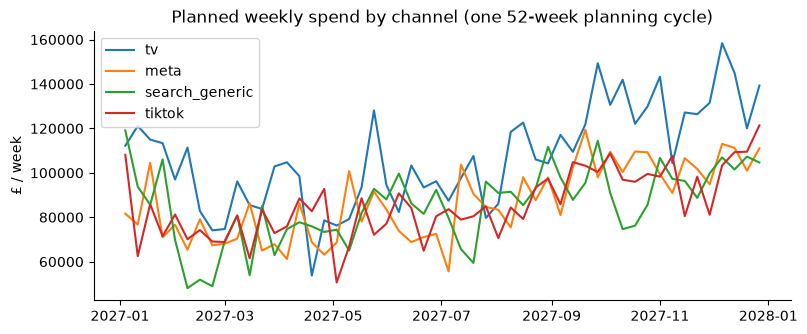

In [3]:
fig, ax = plt.subplots()
for ch in CHANNELS:
    ax.plot(plan_df.index, plan_df[ch], label=ch)
ax.set_title("Planned weekly spend by channel (one 52-week planning cycle)")
ax.set_ylabel("£ / week")
ax.legend()
plt.show()

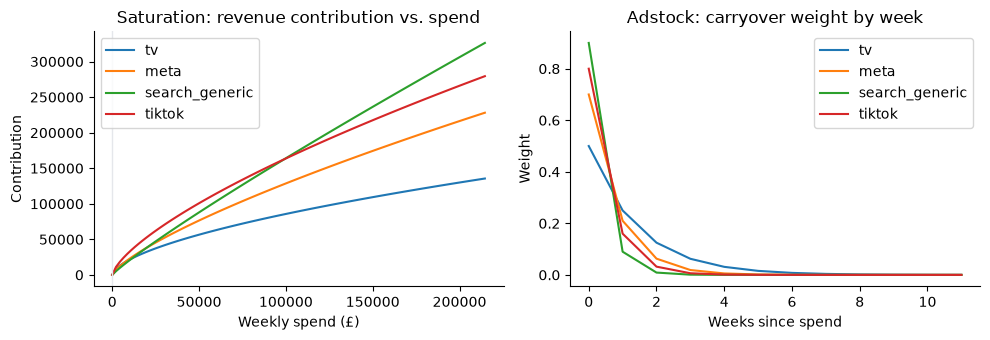

In [4]:
# Saturation: contribution = k * spend**b, k chosen so the marginal return
# at reference_spend equals true_marginal_returns (see _dgp.channel_contributions
# docstring) -- same closed form the package uses internally, not a fresh model.
# Adstock: apply_adstock's own impulse response, (1-lambda) * lambda**t.
spend_grid = np.linspace(1, 2 * max(report.reference_spend_.values()), 100)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ch in CHANNELS:
    b, ref, mr = (
        report.saturation[ch],
        report.reference_spend_[ch],
        report.true_marginal_returns[ch],
    )
    k = mr / (b * ref ** (b - 1)) if b != 1.0 else mr / ref
    axes[0].plot(spend_grid, k * spend_grid**b, label=ch)
axes[0].axvline(0, color="#e5e7eb", lw=1)
axes[0].set_title("Saturation: revenue contribution vs. spend")
axes[0].set_xlabel("Weekly spend (£)")
axes[0].set_ylabel("Contribution")
axes[0].legend()

weeks = np.arange(12)
for ch in CHANNELS:
    lam = report.adstock[ch]
    axes[1].plot(weeks, (1 - lam) * lam**weeks, label=ch)
axes[1].set_title("Adstock: carryover weight by week")
axes[1].set_xlabel("Weeks since spend")
axes[1].set_ylabel("Weight")
axes[1].legend()
plt.tight_layout()
plt.show()

## 2 · The problem

Unphased: variance, bias, adstock and saturation, all from one `results_["unphased"]`.

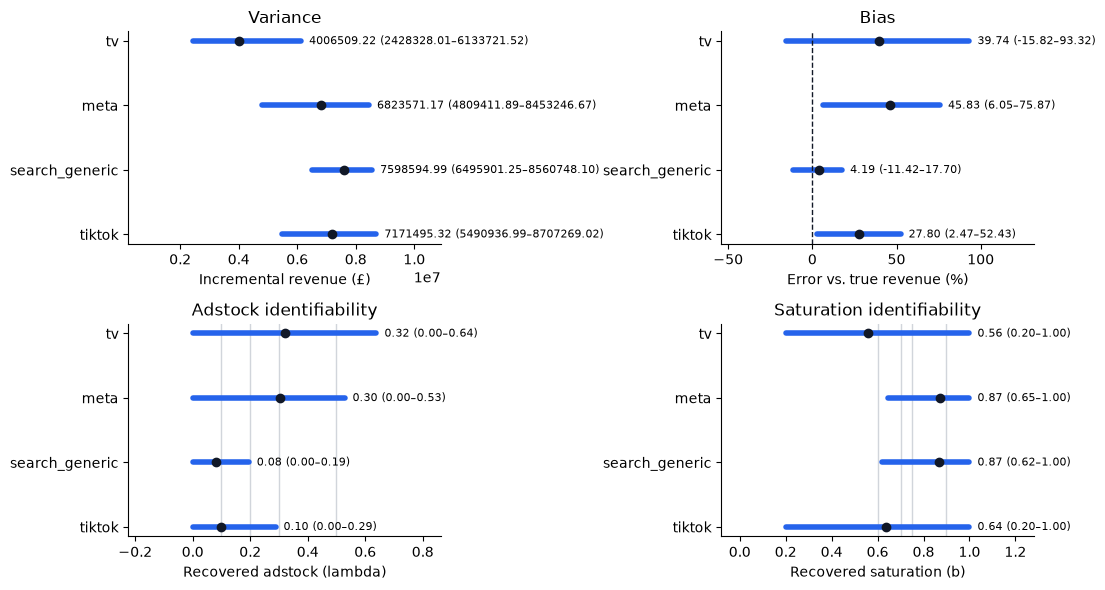

In [5]:
def forest(ax, rows, true=None, xlabel=""):
    """rows: list of (channel, lo, point, hi), channel 0 drawn at the top."""
    ys = list(range(len(rows)))[::-1]
    for y, (ch, lo, point, hi) in zip(ys, rows):
        ax.plot([lo, hi], [y, y], color="#2563eb", lw=4, solid_capstyle="round")
        ax.plot(point, y, "o", color="#111827", zorder=3)
        ax.text(hi, y, f"  {point:.2f} ({lo:.2f}–{hi:.2f})", va="center", fontsize=8)
    if true is not None:
        ax.axvline(true, color="#111827", ls="--", lw=1)
    ax.set_yticks(ys, [ch for ch, *_ in rows])
    ax.set_xlabel(xlabel)
    ax.margins(x=0.35)


u = report.results_["unphased"]
fig, axes = plt.subplots(2, 2, figsize=(11, 6))

forest(
    axes[0, 0],
    [
        (ch, u["revenue_p10"][ch], u["revenue_mean"][ch], u["revenue_p90"][ch])
        for ch in CHANNELS
    ],
    xlabel="Incremental revenue (£)",
)
axes[0, 0].set_title("Variance")

forest(
    axes[0, 1],
    [
        (ch, u["bias_pct_p10"][ch], u["bias_pct"][ch], u["bias_pct_p90"][ch])
        for ch in CHANNELS
    ],
    true=0.0,
    xlabel="Error vs. true revenue (%)",
)
axes[0, 1].set_title("Bias")

forest(
    axes[1, 0],
    [
        (ch, u["lam_p10"][ch], u["identifiability"][ch]["lam_mean"], u["lam_p90"][ch])
        for ch in CHANNELS
    ],
    true=None,
    xlabel="Recovered adstock (lambda)",
)
for ch, y in zip(CHANNELS, range(len(CHANNELS))[::-1]):
    axes[1, 0].axvline(TRUE_ADSTOCK[ch], color="#d1d5db", lw=1, zorder=0)
axes[1, 0].set_title("Adstock identifiability")

forest(
    axes[1, 1],
    [
        (ch, u["b_p10"][ch], u["identifiability"][ch]["b_mean"], u["b_p90"][ch])
        for ch in CHANNELS
    ],
    xlabel="Recovered saturation (b)",
)
for ch in CHANNELS:
    axes[1, 1].axvline(TRUE_SATURATION[ch], color="#d1d5db", lw=1, zorder=0)
axes[1, 1].set_title("Saturation identifiability")

plt.tight_layout()
plt.show()

## 3 · The cause

Same weekly spend as Inputs -- why the model can't tell channels apart.

mean pairwise correlation (unphased): 0.70


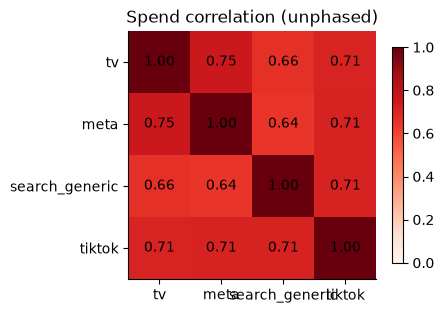

In [6]:
corr = pd.DataFrame(u["correlation"])
mean_pairwise = (corr.values.sum() - len(CHANNELS)) / (
    len(CHANNELS) ** 2 - len(CHANNELS)
)
print(f"mean pairwise correlation (unphased): {mean_pairwise:.2f}")

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(corr.loc[CHANNELS, CHANNELS], vmin=0, vmax=1, cmap="Reds")
ax.set_xticks(range(len(CHANNELS)), CHANNELS)
ax.set_yticks(range(len(CHANNELS)), CHANNELS)
for i, a in enumerate(CHANNELS):
    for j, b in enumerate(CHANNELS):
        ax.text(j, i, f"{corr.loc[a, b]:.2f}", ha="center", va="center")
ax.set_title("Spend correlation (unphased)")
plt.colorbar(im, shrink=0.8)
plt.show()

## 4 · What that correlation costs you

Sweep correlation, everything else fixed, refit, measure TV's range width.

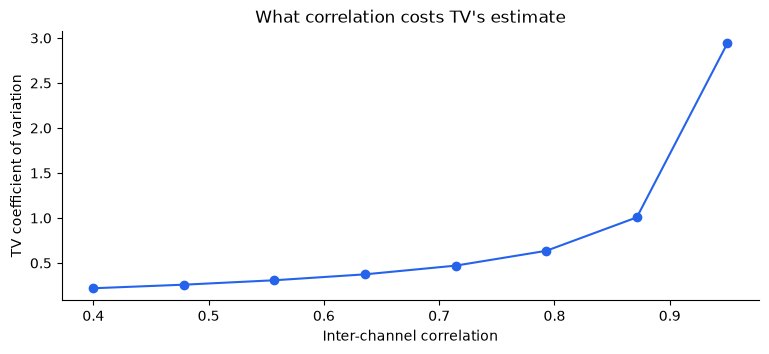

In [7]:
correlations = np.linspace(
    0.4, 0.95, 8
)  # simulate_spend's noise scaling makes spend go negative below ~0.4 at this scale/n_obs
widths = []
for c in correlations:
    h, p = scenario_spend(correlation=c)
    diag = CollinearityDiagnostic(
        spend_df=pd.concat([h, p]),
        true_marginal_returns=TRUE_MARGINAL_RETURNS,
        saturation=TRUE_SATURATION,
        adstock=TRUE_ADSTOCK,
    )
    diag.fit(n_sims=20)
    s = diag.summary(planned_spend=p).set_index("channel")
    widths.append(s.loc["tv", "coef_of_variation"])

fig, ax = plt.subplots()
ax.plot(correlations, widths, marker="o", color="#2563eb")
ax.set_xlabel("Inter-channel correlation")
ax.set_ylabel("TV coefficient of variation")
ax.set_title("What correlation costs TV's estimate")
plt.show()

## 5 · The algorithm

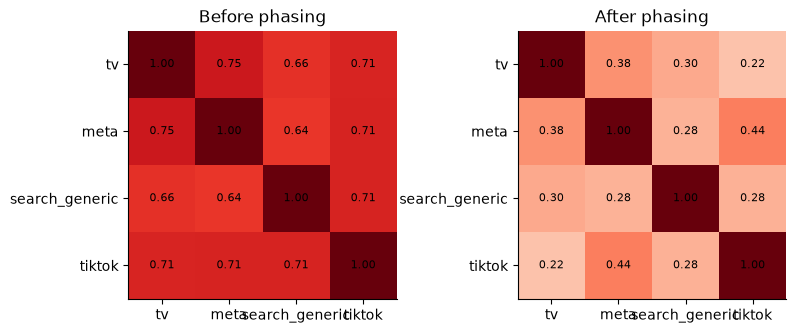

In [8]:
winner_corr = pd.DataFrame(report.results_[report.winner_]["correlation"])
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (label, m) in zip(
    axes, [("Before phasing", corr), ("After phasing", winner_corr)]
):
    im = ax.imshow(m.loc[CHANNELS, CHANNELS], vmin=0, vmax=1, cmap="Reds")
    ax.set_xticks(range(len(CHANNELS)), CHANNELS)
    ax.set_yticks(range(len(CHANNELS)), CHANNELS)
    for i, a in enumerate(CHANNELS):
        for j, b in enumerate(CHANNELS):
            ax.text(j, i, f"{m.loc[a, b]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(label)
plt.tight_layout()
plt.show()

                              variance (CV)  bias (|%|)  identifiability (valley %)
unphased                              0.256      29.389                      41.080
+/-20% (uniform)                      0.230      29.584                      39.980
+/-20% (edge, balanced)               0.196      29.188                      37.838
+/-20% (seesaw)                       0.206      30.744                      36.698
+/-20% (redistribute + edge)          0.088      17.125                      11.852
+/-20% (month step)                   0.163      27.933                      36.087
Blackout (dark=1)                     0.089      21.125                      15.127


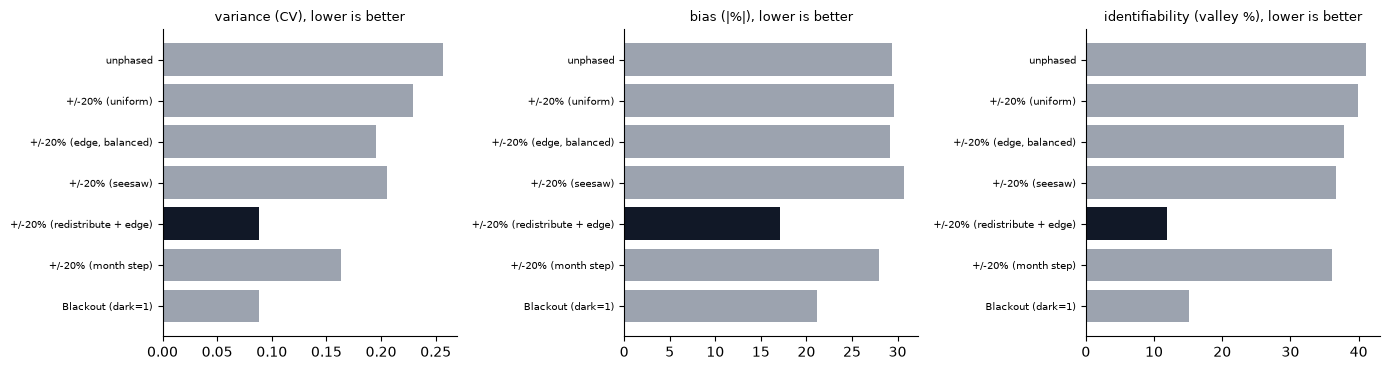

In [9]:
# Every candidate in the sweep on the three report-wide scores (the
# mean-across-channel criterion _pick_winner uses), so this is the same
# evidence the winner was picked from, not a fresh computation.
labels = [label for label, *_ in report.levers_]
scores = pd.DataFrame(
    {
        "variance (CV)": [report.results_[lb]["scores"]["variance"] for lb in labels],
        "bias (|%|)": [report.results_[lb]["scores"]["bias"] for lb in labels],
        "identifiability (valley %)": [
            report.results_[lb]["scores"]["identifiability"] for lb in labels
        ],
    },
    index=labels,
)
print(scores.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, col in zip(axes, scores.columns):
    colors = ["#111827" if lb == report.winner_ else "#9ca3af" for lb in labels]
    ax.barh(labels[::-1], scores[col][::-1], color=colors[::-1])
    ax.set_title(f"{col}, lower is better", fontsize=9)
    ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

## 6 · Impact

`report.winner_` vs. unphased, across all four metrics, plus its Cost. On
this scenario that is `+/-20% (redistribute + edge)`. Bias is shown as
points reduced, not a relative %, because a channel's bias can cross zero.

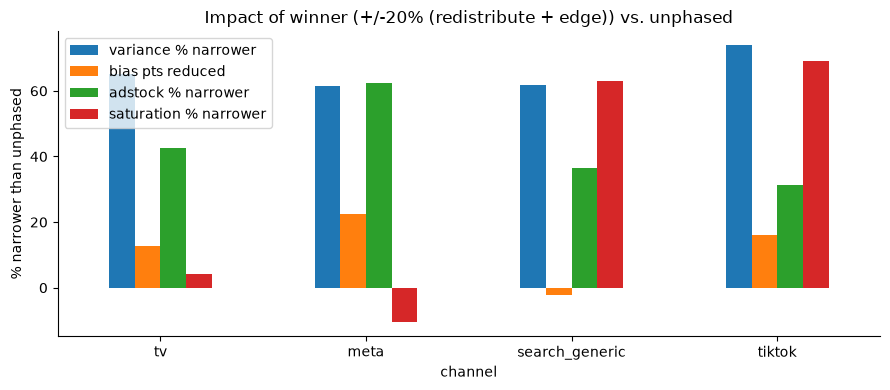

,variance % narrower,bias pts reduced,adstock % narrower,saturation % narrower
channel,,,,
tv,65.1,12.6,42.6,4.1
meta,61.4,22.4,62.4,-10.5
search_generic,61.7,-2.1,36.5,63.1
tiktok,73.9,16.2,31.4,69.2


In [10]:
w = report.results_[report.winner_]


def improvement(before, after):
    return 0.0 if before == 0 else 100 * (before - after) / before


rows = []
for ch in CHANNELS:
    rows.append(
        {
            "channel": ch,
            "variance % narrower": improvement(
                u["variance_cv"][ch], w["variance_cv"][ch]
            ),
            "bias pts reduced": abs(u["bias_pct"][ch])
            - abs(
                w["bias_pct"][ch]
            ),  # pp reduction, not relative -- bias crosses zero, relative % is undefined there
            "adstock % narrower": improvement(
                u["identifiability"][ch]["lam_sd"], w["identifiability"][ch]["lam_sd"]
            ),
            "saturation % narrower": improvement(
                u["identifiability"][ch]["b_sd"], w["identifiability"][ch]["b_sd"]
            ),
        }
    )
impact_table = pd.DataFrame(rows).set_index("channel")

impact_table.plot(
    kind="bar",
    figsize=(9, 4),
    title=f"Impact of winner ({report.winner_}) vs. unphased",
)
plt.ylabel("% narrower than unphased")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
impact_table.round(1)

In [11]:
# Cost: same formula _discovery_report.py uses for the report's own Cost
# callout -- true (unphased) revenue vs. the winner schedule's revenue,
# under the assumed response curve. Zero when saturation is linear.
combined_unphased = pd.concat([report.history_df, report.plan_df])
true_contributions = channel_contributions(
    combined_unphased,
    report.true_marginal_returns,
    report.saturation,
    report.adstock,
    report.reference_spend_,
)
true_revenue = {
    ch: float(true_contributions[ch].iloc[-len(report.plan_df) :].sum())
    for ch in CHANNELS
}

combined_winner = pd.concat([report.history_df, report.winner_schedule_])
winner_contributions = channel_contributions(
    combined_winner,
    report.true_marginal_returns,
    report.saturation,
    report.adstock,
    report.reference_spend_,
)
winner_revenue = {
    ch: float(winner_contributions[ch].iloc[-len(report.plan_df) :].sum())
    for ch in CHANNELS
}

# Same direction as _discovery_report.py's own lever_cost_pct: positive
# means revenue given up (winner_revenue < true_revenue).
cost_pct = {ch: improvement(true_revenue[ch], winner_revenue[ch]) for ch in CHANNELS}
print(
    f"Cost of {report.winner_}: {np.mean(list(cost_pct.values())):.2f}% of true plan-period revenue, mean across channels"
)
pd.Series(cost_pct, name="cost %").round(2)

Cost of +/-20% (redistribute + edge): 1.94% of true plan-period revenue, mean across channels


tv                1.82
meta              2.43
search_generic    1.18
tiktok            2.35
Name: cost %, dtype: float64

## 7 · Phased spend

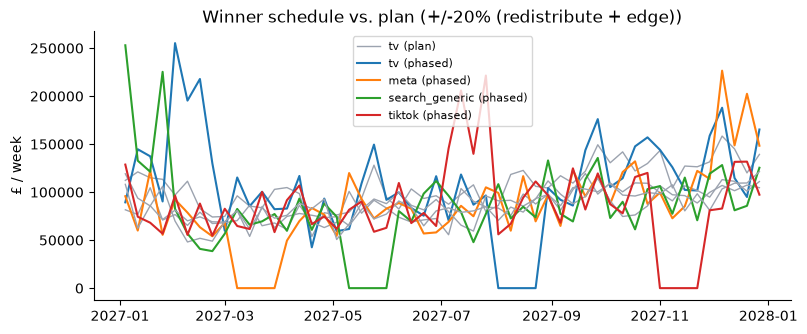

In [12]:
fig, ax = plt.subplots()
for ch in CHANNELS:
    ax.plot(
        plan_df.index,
        plan_df[ch],
        color="#9ca3af",
        lw=1,
        label=f"{ch} (plan)" if ch == "tv" else None,
    )
    ax.plot(
        report.winner_schedule_.index,
        report.winner_schedule_[ch],
        label=f"{ch} (phased)",
    )
ax.set_title(f"Winner schedule vs. plan ({report.winner_})")
ax.set_ylabel("£ / week")
ax.legend(fontsize=8)
plt.show()